# FluNet Data Audit: Japan

This notebook checks whether the WHO FluNet data can provide a clear weekly measure of influenza activity in Japan.

The audit follows three steps:

1. Understand the dataset and identify the Japan records.
2. Check the completeness and consistency of the main influenza variables.
3. Compare two possible measures of influenza activity.

### Option 1: Influenza Positivity Rate

$$\text{Influenza Positivity Rate} = \frac{\text{Influenza Positive Specimens}}{\text{Total Specimens Tested}} \times 100$$

This option adjusts the positive count by the number of specimens tested.

### Option 2: Weekly Influenza-Positive Specimen Count

$$\text{Influenza Activity} = \text{Weekly Positive Specimen Count}$$

This option uses the reported weekly positive count directly.

The goal is to identify which option has enough reliable data for a multi-year study. No temperature analysis or statistical relationship testing is performed in this notebook.

# Import Libraries

Only the libraries needed to inspect, summarize, and plot the data are imported.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("dataset/VIW_FNT.csv")

# FluNet Dataset Overview

This section checks the file size, columns, country coverage, time coverage, and basic data quality. These checks are needed before choosing an influenza activity variable.

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

print("The top 5 rows:")
display(df.head())

print("The last 5 rows:")
display(df.tail())

print("Data Info:")
df.info()

Dataset shape: 187,331 rows × 53 columns
The top 5 rows:


,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
0,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-02,2017,1,2017-01-01,...,NaN,NaN,NaN,NaN,AW,201701,201701,NaN,NaN,NaN
1,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-09,2017,2,2017-01-08,...,NaN,NaN,NaN,NaN,AW,201702,201702,NaN,NaN,NaN
2,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,NaN,AW,201703,201703,NaN,NaN,NaN
3,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-23,2017,4,2017-01-22,...,NaN,NaN,NaN,NaN,AW,201704,201704,NaN,NaN,NaN
4,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-30,2017,5,2017-01-29,...,NaN,NaN,NaN,NaN,AW,201705,201705,NaN,NaN,NaN


The last 5 rows:


,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
187326,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2026-07-06,2026,28,2026-07-05,...,NaN,NaN,NaN,NaN,ZW,202628,202627,NaN,NaN,NaN
187327,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2026-07-13,2026,29,2026-07-12,...,NaN,NaN,NaN,NaN,ZW,202629,202628,NaN,NaN,NaN
187328,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2026-07-20,2026,30,2026-07-19,...,NaN,NaN,NaN,NaN,ZW,202630,202629,NaN,NaN,NaN
187329,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2026-07-27,2026,31,2026-07-26,...,NaN,NaN,NaN,NaN,ZW,202631,202630,NaN,NaN,NaN
187330,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2026-08-03,2026,32,2026-08-02,...,NaN,NaN,NaN,NaN,ZW,202632,202631,NaN,NaN,NaN


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187331 entries, 0 to 187330
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   WHOREGION                187331 non-null  object 
 1   FLUSEASON                187331 non-null  object 
 2   HEMISPHERE               187331 non-null  object 
 3   ITZ                      187331 non-null  object 
 4   COUNTRY_CODE             187331 non-null  object 
 5   COUNTRY_AREA_TERRITORY   187331 non-null  object 
 6   ISO_WEEKSTARTDATE        187331 non-null  object 
 7   ISO_YEAR                 187331 non-null  int64  
 8   ISO_WEEK                 187331 non-null  int64  
 9   MMWR_WEEKSTARTDATE       187331 non-null  object 
 10  MMWR_YEAR                187331 non-null  int64  
 11  MMWR_WEEK                187331 non-null  int64  
 12  ORIGIN_SOURCE            187331 non-null  object 
 13  SPEC_PROCESSED_NB        174402 non-null  float6

In [4]:
structure_summary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "unique_values": df.nunique(dropna=True).values,
})
structure_summary

,column_name,data_type,missing_values,unique_values
0,WHOREGION,object,0,6
1,FLUSEASON,object,0,3
2,HEMISPHERE,object,0,2
3,ITZ,object,0,18
4,COUNTRY_CODE,object,0,189
5,COUNTRY_AREA_TERRITORY,object,0,189
6,ISO_WEEKSTARTDATE,object,0,1624
7,ISO_YEAR,int64,0,32
8,ISO_WEEK,int64,0,53
9,MMWR_WEEKSTARTDATE,object,0,1624


## Identify Japan Data

The FluNet file contains many countries. We first identify the country column and create `df_japan` without changing the original DataFrame.

In [5]:
country_columns = ["COUNTRY_CODE", "COUNTRY_AREA_TERRITORY", "ISO2"]
country_lookup = (
    df[country_columns]
    .drop_duplicates()
    .sort_values("COUNTRY_AREA_TERRITORY")
    .reset_index(drop=True)
)

print(f"Number of countries/areas: {df['COUNTRY_AREA_TERRITORY'].nunique()}")
display(country_lookup)

Number of countries/areas: 189


,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO2
0,AFG,Afghanistan,AF
1,ALB,Albania,AL
2,DZA,Algeria,DZ
3,AGO,Angola,AO
4,AIA,Anguilla,AI
...,...,...,...
184,VNM,Viet Nam,VN
185,YEM,Yemen,YE
186,ZMB,Zambia,ZM
187,ZWE,Zimbabwe,ZW


In [6]:
japan_values = country_lookup[
    country_lookup["COUNTRY_AREA_TERRITORY"].str.contains("Japan", case=False, na=False)
]
display(japan_values)

,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO2
81,JPN,Japan,JP


In [7]:
df_japan = df[df["COUNTRY_AREA_TERRITORY"] == "Japan"].copy()
print(f"Japan subset shape: {df_japan.shape[0]:,} rows × {df_japan.shape[1]:,} columns")
df_japan[["COUNTRY_CODE", "COUNTRY_AREA_TERRITORY", "ISO2", "ORIGIN_SOURCE"]].drop_duplicates()

Japan subset shape: 1,522 rows × 53 columns


,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO2,ORIGIN_SOURCE
84839,JPN,Japan,JP,SENTINEL


## Identify Relevant FluNet Variables

The variables below are the main candidates for defining weekly influenza activity.

| Concept | FluNet Column | Meaning in this audit |
| --- | --- | --- |
| Year | `ISO_YEAR` | ISO epidemiological year |
| Week | `ISO_WEEK` | ISO epidemiological week, from 1 to 53 |
| Week start date | `ISO_WEEKSTARTDATE` | Start date of the ISO week |
| Influenza A positive | `INF_A` | Specimens reported positive for influenza A |
| Influenza B positive | `INF_B` | Specimens reported positive for influenza B |
| Total influenza positive | `INF_ALL` | Candidate total positive count |
| Specimens processed | `SPEC_PROCESSED_NB` | Candidate number of specimens tested or processed |

Influenza A and B are the main influenza virus types that cause seasonal influenza in humans. Influenza A includes subtypes such as A(H1N1)pdm09 and A(H3N2). Influenza B is reported separately and may include lineage information.

`INF_A`, `INF_B`, and `INF_ALL` are laboratory surveillance specimen counts. They are not the total number of influenza cases in Japan.

In [8]:
candidate_columns = [
    "ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE",
    "INF_A", "INF_B", "INF_ALL",
    "SPEC_PROCESSED_NB", "SPEC_RECEIVED_NB", "INF_NEGATIVE",
]
display(df_japan[candidate_columns].head(12))

,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,INF_A,INF_B,INF_ALL,SPEC_PROCESSED_NB,SPEC_RECEIVED_NB,INF_NEGATIVE
84839,1996,41,1996-10-07,1.0,0.0,1.0,NaN,NaN,NaN
84840,1996,42,1996-10-14,2.0,0.0,2.0,NaN,NaN,NaN
84841,1996,43,1996-10-21,1.0,0.0,1.0,NaN,NaN,NaN
84842,1996,44,1996-10-28,4.0,0.0,4.0,NaN,NaN,NaN
84843,1996,45,1996-11-04,11.0,0.0,11.0,NaN,NaN,NaN
84844,1996,46,1996-11-11,12.0,0.0,12.0,NaN,NaN,NaN
84845,1996,47,1996-11-18,25.0,1.0,26.0,NaN,NaN,NaN
84846,1996,48,1996-11-25,63.0,2.0,65.0,NaN,NaN,NaN
84847,1996,49,1996-12-02,190.0,4.0,194.0,NaN,NaN,NaN
84848,1996,50,1996-12-09,433.0,3.0,436.0,NaN,NaN,NaN


In [9]:
sample_values = pd.DataFrame({
    "column": candidate_columns,
    "sample_non_missing_values": [
        df_japan[column].dropna().drop_duplicates().head(8).tolist()
        for column in candidate_columns
    ],
})
display(sample_values)

,column,sample_non_missing_values
0,ISO_YEAR,"[1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003]"
1,ISO_WEEK,"[41, 42, 43, 44, 45, 46, 47, 48]"
2,ISO_WEEKSTARTDATE,"[1996-10-07, 1996-10-14, 1996-10-21, 1996-10-2..."
3,INF_A,"[1.0, 2.0, 4.0, 11.0, 12.0, 25.0, 63.0, 190.0]"
4,INF_B,"[0.0, 1.0, 2.0, 4.0, 3.0, 10.0, 8.0, 19.0]"
5,INF_ALL,"[1.0, 2.0, 4.0, 11.0, 12.0, 26.0, 65.0, 194.0]"
6,SPEC_PROCESSED_NB,"[1148.0, 1144.0, 1167.0, 966.0, 828.0, 1150.0,..."
7,SPEC_RECEIVED_NB,[]
8,INF_NEGATIVE,"[2.0, 6.0, 7.0, 4.0, 0.0, 8.0, 9.0, 13.0]"


## Time Coverage

We check the first year, last year, and number of records per year. This shows whether the file contains full years or partial years.

In [10]:
year_summary = pd.Series({
    "minimum_year": df_japan["ISO_YEAR"].min(),
    "maximum_year": df_japan["ISO_YEAR"].max(),
    "number_of_unique_years": df_japan["ISO_YEAR"].nunique(),
})
display(year_summary)

minimum_year              1996
maximum_year              2026
number_of_unique_years      31
dtype: int64

In [11]:
records_per_year = (
    df_japan.groupby("ISO_YEAR")
    .size()
    .rename("number_of_records")
    .to_frame()
)
display(records_per_year)

,number_of_records
ISO_YEAR,
1996,12
1997,20
1998,51
1999,52
2000,51
2001,52
2002,52
2003,52
2004,53


In [12]:
week_summary = pd.Series({
    "minimum_week": df_japan["ISO_WEEK"].min(),
    "maximum_week": df_japan["ISO_WEEK"].max(),
    "number_of_unique_weeks": df_japan["ISO_WEEK"].nunique(),
})
print(week_summary)
print("Unique epidemiological weeks:")
print(sorted(df_japan["ISO_WEEK"].unique()))

minimum_week               1
maximum_week              53
number_of_unique_weeks    53
dtype: int64
Unique epidemiological weeks:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53)]


## Year–Week Structure

The intended unit is one row per ISO week. We compare the number of rows with the number of unique year–week combinations and check for duplicates.

In [13]:
df_japan["year_week"] = (
    df_japan["ISO_YEAR"].astype(str)
    + "-W"
    + df_japan["ISO_WEEK"].astype(str).str.zfill(2)
)

duplicate_mask = df_japan.duplicated(["ISO_YEAR", "ISO_WEEK"], keep=False)
year_week_summary = pd.Series({
    "total_rows": len(df_japan),
    "unique_year_week_combinations": df_japan[["ISO_YEAR", "ISO_WEEK"]].drop_duplicates().shape[0],
    "rows_in_duplicated_year_weeks": int(duplicate_mask.sum()),
    "extra_duplicated_year_week_rows": int(
        df_japan.duplicated(["ISO_YEAR", "ISO_WEEK"]).sum()
    ),
})
display(year_week_summary)

total_rows                         1522
unique_year_week_combinations      1522
rows_in_duplicated_year_weeks         0
extra_duplicated_year_week_rows       0
dtype: int64

In [14]:
duplicated_records = df_japan.loc[duplicate_mask].sort_values(
    ["ISO_YEAR", "ISO_WEEK"]
)

if duplicated_records.empty:
    print("No duplicated ISO year–week records were found for Japan.")
else:
    display(duplicated_records)
    differing_columns = [
        column for column in duplicated_records.columns
        if duplicated_records.groupby(["ISO_YEAR", "ISO_WEEK"])[column]
        .nunique(dropna=False).gt(1).any()
    ]
    print("Columns that differ within at least one duplicated year–week:")
    print(differing_columns)

No duplicated ISO year–week records were found for Japan.


## Missing Values

Missing values are counted for the variables needed by both activity options. A missing value means the information is not available; it is not automatically treated as zero.

In [15]:
relevant_columns = [
    "ISO_YEAR", "ISO_WEEK", "INF_A", "INF_B", "INF_ALL",
    "SPEC_PROCESSED_NB", "SPEC_RECEIVED_NB", "INF_NEGATIVE",
]

missing_summary = pd.DataFrame({
    "missing_values": df_japan[relevant_columns].isna().sum(),
    "missing_percent": df_japan[relevant_columns].isna().mean().mul(100).round(2),
})
display(missing_summary)

,missing_values,missing_percent
ISO_YEAR,0,0.00
ISO_WEEK,0,0.00
INF_A,20,1.31
INF_B,18,1.18
INF_ALL,246,16.16
SPEC_PROCESSED_NB,1452,95.40
SPEC_RECEIVED_NB,1522,100.00
INF_NEGATIVE,1186,77.92


In [16]:
# Coverage by year helps reveal whether missingness is concentrated in time.
non_missing_by_year = df_japan.groupby("ISO_YEAR")[[
    "INF_A", "INF_B", "INF_ALL", "SPEC_PROCESSED_NB", "INF_NEGATIVE"
]].count()
display(non_missing_by_year)

,INF_A,INF_B,INF_ALL,SPEC_PROCESSED_NB,INF_NEGATIVE
ISO_YEAR,,,,,
1996,12,12,12,0,0
1997,17,15,17,0,0
1998,40,38,26,0,0
1999,52,52,33,0,0
2000,51,51,29,0,0
2001,52,52,41,0,0
2002,52,52,36,0,0
2003,52,52,38,0,0
2004,53,53,44,0,0


## Numerical Validity

We check the range of the main count variables and look for negative or zero values. Negative specimen counts would indicate a data problem. Zero can be valid when no positive specimens were reported.

In [17]:
numeric_influenza_columns = [
    "INF_A", "INF_B", "INF_ALL", "SPEC_PROCESSED_NB", "INF_NEGATIVE"
]

numeric_validity = pd.DataFrame({
    "minimum": df_japan[numeric_influenza_columns].min(),
    "maximum": df_japan[numeric_influenza_columns].max(),
    "mean": df_japan[numeric_influenza_columns].mean(),
    "median": df_japan[numeric_influenza_columns].median(),
    "negative_values": (df_japan[numeric_influenza_columns] < 0).sum(),
    "zero_values": (df_japan[numeric_influenza_columns] == 0).sum(),
})
numeric_validity

,minimum,maximum,mean,median,negative_values,zero_values
INF_A,0.0,1656.0,112.820240,16.0,0,293
INF_B,0.0,576.0,31.910904,3.0,0,510
INF_ALL,1.0,1656.0,170.415361,48.5,0,0
SPEC_PROCESSED_NB,54.0,1273.0,905.900000,1038.5,0,0
INF_NEGATIVE,0.0,6599.0,828.514881,49.0,0,1


In [18]:
processed_checks = pd.Series({
    "missing_values": df_japan["SPEC_PROCESSED_NB"].isna().sum(),
    "zero_values": df_japan["SPEC_PROCESSED_NB"].eq(0).sum(),
    "negative_values": df_japan["SPEC_PROCESSED_NB"].lt(0).sum(),
})
processed_checks

missing_values     1452
zero_values           0
negative_values       0
dtype: int64

## Check the Positive Count Variables

If `INF_ALL` is the total positive count, it should equal `INF_A + INF_B`. The comparison uses only rows where all three values are available. Missing values are not changed, and the original columns remain unchanged.

In [19]:
positive_comparison = df_japan.loc[
    df_japan[["INF_A", "INF_B", "INF_ALL"]].notna().all(axis=1),
    ["ISO_YEAR", "ISO_WEEK", "INF_A", "INF_B", "INF_ALL"],
].copy()

positive_comparison["INF_A_plus_INF_B"] = (
    positive_comparison["INF_A"] + positive_comparison["INF_B"]
)
positive_comparison["matches_INF_ALL"] = (
    positive_comparison["INF_A_plus_INF_B"] == positive_comparison["INF_ALL"]
)

comparison_summary = pd.Series({
    "comparable_rows": len(positive_comparison),
    "matching_rows": positive_comparison["matches_INF_ALL"].sum(),
    "non_matching_rows": (~positive_comparison["matches_INF_ALL"]).sum(),
})
comparison_summary

comparable_rows      1267
matching_rows        1267
non_matching_rows       0
dtype: int64

## Dataset Overview Summary

- The file contains **187,331 records from 189 countries or areas**.
- Japan has **1,522 weekly records covering 1996–2026**.
- Each Japan row has a unique ISO year–week; no duplicate weeks were found.
- `INF_A`, `INF_B`, and `INF_ALL` are the main positive-count variables.
- `SPEC_PROCESSED_NB` is the main denominator candidate, but it is missing for most Japan records.
- The next step is to test whether each activity option has enough data for multi-year analysis.

# Option 1: Influenza Positivity Rate

Influenza positivity rate is the percentage of tested specimens that are positive for influenza.

$$\text{Influenza Positivity Rate} = \frac{\text{Influenza Positive Specimens}}{\text{Total Specimens Tested}} \times 100$$

This measure needs both a positive count and a tested-specimen count for every week. The main question is whether both variables have enough historical coverage.

In [20]:
non_matching_positive_rows = positive_comparison.loc[
    ~positive_comparison["matches_INF_ALL"]
]

if non_matching_positive_rows.empty:
    print("No non-matching rows were found among rows with all three counts present.")
else:
    display(non_matching_positive_rows.head(10))

No non-matching rows were found among rows with all three counts present.


## Candidate Variables

- **Numerator: `INF_ALL`**  
  This is the most direct total positive-count variable. It matches `INF_A + INF_B` when all three values are reported.

- **Denominator: `SPEC_PROCESSED_NB`**  
  This is the best available candidate for the number of specimens tested or processed.

`SPEC_RECEIVED_NB` cannot be used because it is missing for all Japan records. `INF_NEGATIVE` is not used because the dataset alone does not clearly confirm that it has the same testing scope as `INF_ALL`.

## Preliminary Feasibility Check

The rate is calculated only when `INF_ALL` is available and `SPEC_PROCESSED_NB` is greater than zero.

Weeks with a missing or zero denominator are left without a rate. This is only a basic data check, not the final analysis variable.

In [21]:
rate_check = df_japan.loc[
    df_japan["INF_ALL"].notna() & df_japan["SPEC_PROCESSED_NB"].gt(0),
    ["ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE", "INF_ALL", "SPEC_PROCESSED_NB"],
].copy()

rate_check["positivity_rate"] = (
    rate_check["INF_ALL"] / rate_check["SPEC_PROCESSED_NB"] * 100
)

rate_summary = pd.Series({
    "eligible_rows": len(rate_check),
    "minimum_percent": rate_check["positivity_rate"].min(),
    "maximum_percent": rate_check["positivity_rate"].max(),
    "mean_percent": rate_check["positivity_rate"].mean(),
    "median_percent": rate_check["positivity_rate"].median(),
    "values_outside_0_to_100": (
        ~rate_check["positivity_rate"].between(0, 100)
    ).sum(),
})
rate_summary

eligible_rows              70.000000
minimum_percent             0.165017
maximum_percent            54.136691
mean_percent               14.139230
median_percent              4.516239
values_outside_0_to_100     0.000000
dtype: float64

## Preliminary Visualization

The plot shows only weeks with enough data to calculate positivity rate. It is used to check the calculated range and time coverage, not to interpret influenza patterns.

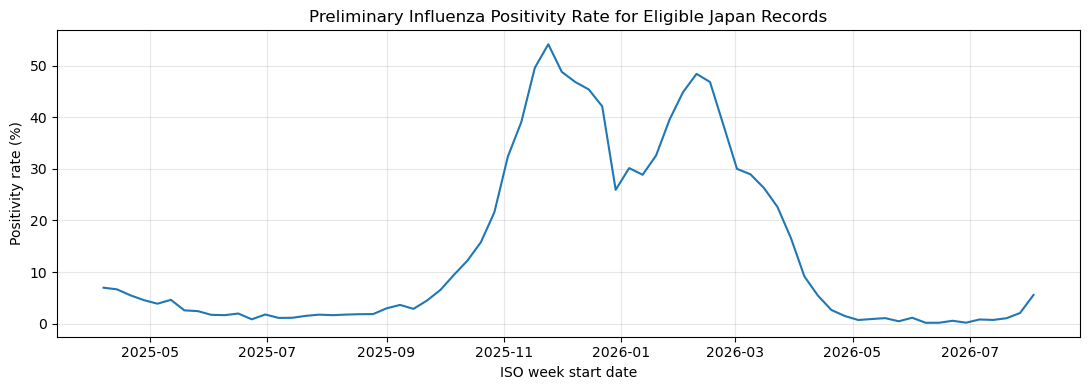

In [22]:
rate_check["week_start_date"] = pd.to_datetime(rate_check["ISO_WEEKSTARTDATE"])
rate_check = rate_check.sort_values("week_start_date")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rate_check["week_start_date"], rate_check["positivity_rate"], linewidth=1.5)
ax.set_title("Preliminary Influenza Positivity Rate for Eligible Japan Records")
ax.set_xlabel("ISO week start date")
ax.set_ylabel("Positivity rate (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Option 1: Key Insights

- `INF_ALL` is the most suitable numerator.
- `SPEC_PROCESSED_NB` is the best denominator candidate, but it is missing in **1,452 of 1,522 weeks (95.40%)**.
- Only **70 weeks in 2025–2026** have enough data to calculate the rate.
- All calculated rates are within the valid range of **0–100%**.
- **Decision:** positivity rate is not suitable for the intended multi-year study because the denominator has very limited coverage.

# Option 2: Weekly Influenza-Positive Specimen Count

This option uses the number of influenza-positive specimens reported each week.

The first choice is `INF_ALL`. If it is missing, `INF_A + INF_B` may provide the same total when both component values are available.

This option does not need a testing denominator, so it may support a longer study period. However, it does not adjust for changes in testing or surveillance activity.

## Build the Candidate Positive Count

We use a conservative rule:

1. Use `INF_ALL` when available.
2. If `INF_ALL` is missing, use `INF_A + INF_B` only when both values are available.
3. Otherwise, leave the value missing.

Missing A or B values are never treated as zero. The new variable is created in `df_positive`, so the original Japan data remain unchanged.

In [23]:
df_positive = df_japan.copy()

can_use_a_plus_b = (
    df_positive["INF_ALL"].isna()
    & df_positive["INF_A"].notna()
    & df_positive["INF_B"].notna()
)

df_positive["positive_specimen_count"] = df_positive["INF_ALL"]
df_positive.loc[can_use_a_plus_b, "positive_specimen_count"] = (
    df_positive.loc[can_use_a_plus_b, "INF_A"]
    + df_positive.loc[can_use_a_plus_b, "INF_B"]
)

df_positive["positive_count_source"] = np.select(
    [df_positive["INF_ALL"].notna(), can_use_a_plus_b],
    ["INF_ALL", "INF_A + INF_B"],
    default="Missing",
)

## Overall Coverage

The first table shows how complete the candidate count is. The second table separates observed `INF_ALL` values, values derived from `INF_A + INF_B`, and unresolved missing values.

In [24]:
positive_count = df_positive["positive_specimen_count"]

overall_positive_coverage = pd.DataFrame([{
    "Total Weeks": len(df_positive),
    "Available": positive_count.notna().sum(),
    "Missing": positive_count.isna().sum(),
    "Coverage %": round(positive_count.notna().mean() * 100, 2),
    "Reported Zeros": positive_count.eq(0).sum(),
    "Negative Values": positive_count.lt(0).sum(),
    "Minimum": positive_count.min(),
    "Maximum": positive_count.max(),
    "Median": positive_count.median(),
}])

source_summary = (
    df_positive["positive_count_source"]
    .value_counts()
    .reindex(["INF_ALL", "INF_A + INF_B", "Missing"], fill_value=0)
    .rename("Weeks")
    .to_frame()
)

display(overall_positive_coverage)
display(source_summary)

,Total Weeks,Available,Missing,Coverage %,Reported Zeros,Negative Values,Minimum,Maximum,Median
0,1522,1505,17,98.88,229,0,0.0,1656.0,30.0


,Weeks
positive_count_source,
INF_ALL,1276
INF_A + INF_B,229
Missing,17


## Coverage by Year

Overall coverage can hide weak years. The yearly table shows which years are complete, which contain missing counts, and which are only partially included in the file.

In [25]:
positive_coverage_by_year = df_positive.groupby("ISO_YEAR").agg(
    Total_Weeks=("ISO_WEEK", "size"),
    Available=("positive_specimen_count", "count"),
)
positive_coverage_by_year["Missing"] = (
    positive_coverage_by_year["Total_Weeks"]
    - positive_coverage_by_year["Available"]
)
positive_coverage_by_year["Coverage %"] = (
    positive_coverage_by_year["Available"]
    / positive_coverage_by_year["Total_Weeks"] * 100
).round(2)

positive_coverage_by_year

,Total_Weeks,Available,Missing,Coverage %
ISO_YEAR,,,,
1996,12,12,0,100.00
1997,20,17,3,85.00
1998,51,42,9,82.35
1999,52,52,0,100.00
2000,51,51,0,100.00
2001,52,52,0,100.00
2002,52,52,0,100.00
2003,52,52,0,100.00
2004,53,53,0,100.00


## Missing Weeks

These weeks remain missing because `INF_ALL` is unavailable and `INF_A + INF_B` cannot be calculated. They are kept as missing and are not filled or interpolated.

In [26]:
missing_positive_weeks = df_positive.loc[
    df_positive["positive_specimen_count"].isna(),
    ["ISO_YEAR", "ISO_WEEK", "ISO_WEEKSTARTDATE", "INF_A", "INF_B", "INF_ALL"],
].copy()

missing_weeks_by_year = (
    missing_positive_weeks.groupby("ISO_YEAR")
    .size()
    .rename("Missing Weeks")
    .to_frame()
)

display(missing_weeks_by_year)
display(missing_positive_weeks)

,Missing Weeks
ISO_YEAR,
1997,3
1998,9
2022,5


,ISO_YEAR,ISO_WEEK,ISO_WEEKSTARTDATE,INF_A,INF_B,INF_ALL
84866,1997,17,1997-04-21,NaN,NaN,NaN
84867,1997,27,1997-06-30,NaN,NaN,NaN
84870,1997,52,1997-12-22,NaN,NaN,NaN
84871,1998,1,1997-12-29,NaN,NaN,NaN
84872,1998,2,1998-01-05,NaN,NaN,NaN
84874,1998,4,1998-01-19,NaN,NaN,NaN
84876,1998,6,1998-02-02,NaN,NaN,NaN
84878,1998,8,1998-02-16,NaN,NaN,NaN
84879,1998,9,1998-02-23,NaN,NaN,NaN
84880,1998,10,1998-03-02,NaN,NaN,NaN


## Possible Study Periods

The table compares several possible periods. It reports their length and missing-data coverage so the study period can be selected manually later. The longest period is not automatically the best choice.

In [27]:
candidate_periods = {
    "1999–2021": (1999, 2021),
    "1999–2025": (1999, 2025),
    "2023–2025": (2023, 2025),
}

period_results = []
for period, (start_year, end_year) in candidate_periods.items():
    period_data = df_positive[df_positive["ISO_YEAR"].between(start_year, end_year)]
    available = period_data["positive_specimen_count"].notna().sum()
    period_results.append({
        "Period": period,
        "Years": end_year - start_year + 1,
        "Total Weeks": len(period_data),
        "Available": available,
        "Missing": len(period_data) - available,
        "Coverage %": round(available / len(period_data) * 100, 2),
    })

period_coverage = pd.DataFrame(period_results).set_index("Period")
period_coverage

,Years,Total Weeks,Available,Missing,Coverage %
Period,,,,,
1999–2021,23,1199,1199,0,100.00
1999–2025,27,1407,1402,5,99.64
2023–2025,3,156,156,0,100.00


## Visual Check

The first plot shows the weekly positive count without smoothing or interpolation. Missing values remain as gaps. The second plot shows the percentage of available weeks in each year.

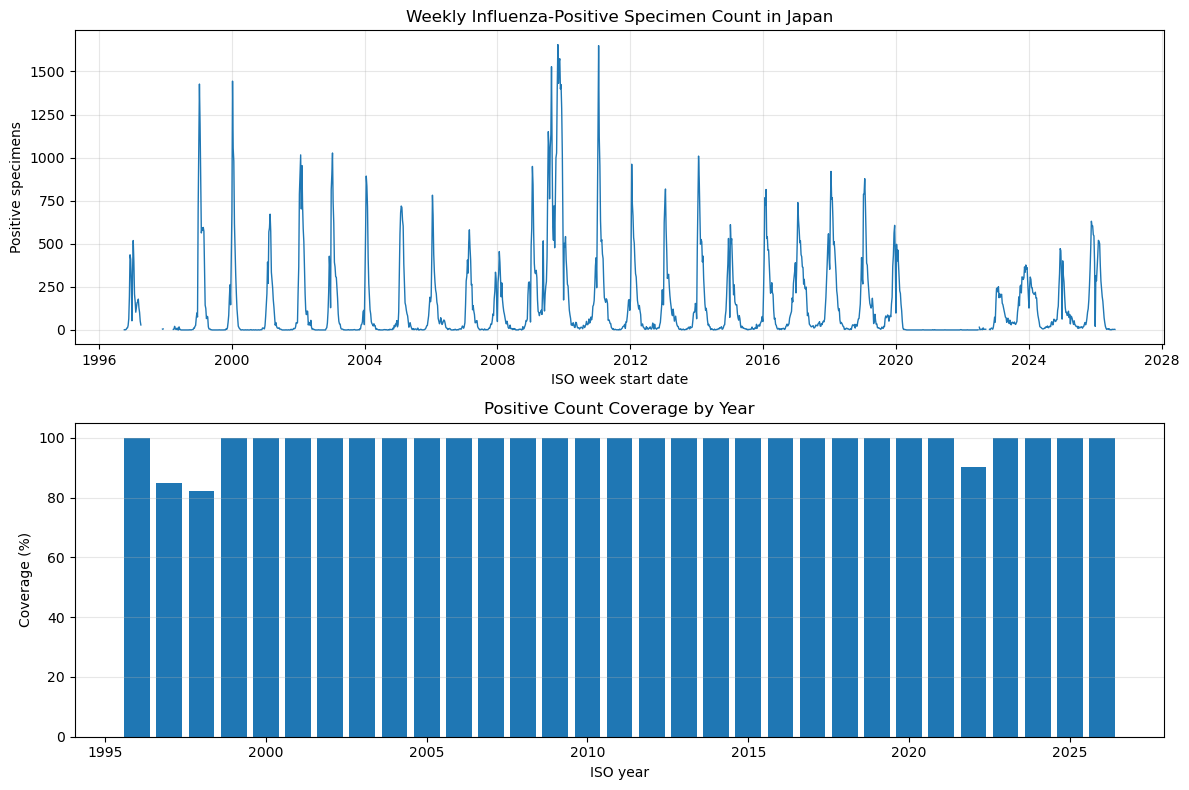

In [28]:
positive_plot_data = df_positive.copy()
positive_plot_data["week_start_date"] = pd.to_datetime(
    positive_plot_data["ISO_WEEKSTARTDATE"]
)
positive_plot_data = positive_plot_data.sort_values("week_start_date")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(
    positive_plot_data["week_start_date"],
    positive_plot_data["positive_specimen_count"],
    linewidth=1,
)
axes[0].set_title("Weekly Influenza-Positive Specimen Count in Japan")
axes[0].set_xlabel("ISO week start date")
axes[0].set_ylabel("Positive specimens")
axes[0].grid(alpha=0.3)

axes[1].bar(
    positive_coverage_by_year.index,
    positive_coverage_by_year["Coverage %"],
)
axes[1].set_title("Positive Count Coverage by Year")
axes[1].set_xlabel("ISO year")
axes[1].set_ylabel("Coverage (%)")
axes[1].set_ylim(0, 105)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Option 2: Key Insights

- `INF_ALL` is missing in **246 weeks**, but **229 weeks** can be recovered from `INF_A + INF_B`.
- The candidate count is available for **1,505 of 1,522 weeks (98.88%)**.
- Only **17 weeks** remain unresolved. They occur in 1997, 1998, and 2022.
- 1996 and 2026 are partial years in the available file.
- **1999–2021** and **2023–2025** have complete candidate-count coverage.
- **1999–2025** is a longer possible period, but it includes five missing weeks in 2022.
- **Decision:** weekly positive specimen count is suitable for multi-year analysis with preprocessing and clear limitations.
- The variable measures specimens reported through FluNet, not all influenza cases in Japan.
- Because the count is not adjusted by the number tested, changes in testing or surveillance may affect comparisons over time.

# Export Japan Analysis-Ready Data

In [29]:
# Keep identifiers, weekly timing, raw counts, and the two candidate activity measures.
japan_export_columns = [
    "WHOREGION",
    "COUNTRY_CODE",
    "COUNTRY_AREA_TERRITORY",
    "ISO2",
    "HEMISPHERE",
    "FLUSEASON",
    "ORIGIN_SOURCE",
    "ISO_WEEKSTARTDATE",
    "ISO_YEAR",
    "ISO_WEEK",
    "ISOYW",
    "INF_A",
    "INF_B",
    "INF_ALL",
    "SPEC_PROCESSED_NB",
    "INF_NEGATIVE",
    "positive_specimen_count",
    "positive_count_source",
]

df_japan_export = df_positive[japan_export_columns].copy()

# Option 1 is calculated only when the reported total and denominator are available.
valid_rate = (
    df_japan_export["INF_ALL"].notna()
    & df_japan_export["SPEC_PROCESSED_NB"].gt(0)
)
df_japan_export["positivity_rate_percent"] = np.nan
df_japan_export.loc[valid_rate, "positivity_rate_percent"] = (
    df_japan_export.loc[valid_rate, "INF_ALL"]
    / df_japan_export.loc[valid_rate, "SPEC_PROCESSED_NB"]
    * 100
)

df_japan_export = df_japan_export.sort_values(
    ["ISO_YEAR", "ISO_WEEK"]
).reset_index(drop=True)

df_japan_export.head(10)

,WHOREGION,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO2,HEMISPHERE,FLUSEASON,ORIGIN_SOURCE,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,ISOYW,INF_A,INF_B,INF_ALL,SPEC_PROCESSED_NB,INF_NEGATIVE,positive_specimen_count,positive_count_source,positivity_rate_percent
0,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-07,1996,41,199641,1.0,0.0,1.0,NaN,NaN,1.0,INF_ALL,NaN
1,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-14,1996,42,199642,2.0,0.0,2.0,NaN,NaN,2.0,INF_ALL,NaN
2,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-21,1996,43,199643,1.0,0.0,1.0,NaN,NaN,1.0,INF_ALL,NaN
3,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-28,1996,44,199644,4.0,0.0,4.0,NaN,NaN,4.0,INF_ALL,NaN
4,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-04,1996,45,199645,11.0,0.0,11.0,NaN,NaN,11.0,INF_ALL,NaN
5,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-11,1996,46,199646,12.0,0.0,12.0,NaN,NaN,12.0,INF_ALL,NaN
6,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-18,1996,47,199647,25.0,1.0,26.0,NaN,NaN,26.0,INF_ALL,NaN
7,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-25,1996,48,199648,63.0,2.0,65.0,NaN,NaN,65.0,INF_ALL,NaN
8,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-12-02,1996,49,199649,190.0,4.0,194.0,NaN,NaN,194.0,INF_ALL,NaN
9,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-12-09,1996,50,199650,433.0,3.0,436.0,NaN,NaN,436.0,INF_ALL,NaN


## Export and Check

In [30]:
JAPAN_OUTPUT_PATH = Path("dataset/flunet_japan_analysis_ready.csv")
df_japan_export.to_csv(JAPAN_OUTPUT_PATH, index=False)

export_summary = pd.DataFrame([{
    "Output File": str(JAPAN_OUTPUT_PATH),
    "Rows": len(df_japan_export),
    "Columns": df_japan_export.shape[1],
    "Duplicate Year-Weeks": df_japan_export.duplicated(
        ["ISO_YEAR", "ISO_WEEK"]
    ).sum(),
    "Option 1 Rates Available": df_japan_export[
        "positivity_rate_percent"
    ].notna().sum(),
    "Option 2 Counts Available": df_japan_export[
        "positive_specimen_count"
    ].notna().sum(),
}])

export_summary

,Output File,Rows,Columns,Duplicate Year-Weeks,Option 1 Rates Available,Option 2 Counts Available
0,dataset/flunet_japan_analysis_ready.csv,1522,19,0,70,1505


## Export Summary

- The CSV contains all **1,522 Japan year–week records** with no duplicate weeks.
- Option 1 has **70 available positivity-rate values**; other weeks remain missing because the denominator is unavailable.
- Option 2 has **1,505 available positive-count values**; 17 weeks remain unresolved.
- The CSV is ready for either option, but the known coverage limitations still apply.